# Teste de Baseline com regressão linear para predição de resistência à compressão

In [121]:
%%capture
!pip install mapie
!pip install optuna

In [122]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, LeaveOneGroupOut
from mapie.regression import SplitConformalRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [123]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão linear Ridge
ridge_file = 'df_resistencia_Ridge.pkl'
ridge_path = os.path.join(dirpath, ridge_file)

df_ridge = pd.read_pickle(ridge_path)
df_ridge['target'] = df_ridge['Resistencia_Compressao_MPa'].copy()
df_ridge.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [125]:
n_groups = df_ridge['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 16


In [126]:
logo = LeaveOneGroupOut()
X = df_ridge.drop(columns=["target", "Autores/ano"])
y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

def objective(trial):

    scores = []

    # 🔹 Hiperparâmetros
    alpha_model = trial.suggest_float("ridge_alpha", 1e-3, 100, log=True)
    alpha_cp = trial.suggest_float("alpha_cp", 0.05, 0.8)  # controla cobertura

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        groups_train = groups.iloc[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        # 🔹 Escalonamento
        scaler = StandardScaler().set_output(transform="pandas")
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        preds_models = []
        residuals = []

        # 🔹 Jackknife (Leave-One-Group-Out)
        for sub_train_idx, sub_test_idx in logo.split(X_train, y_train, groups_train):

            X_sub_train = X_train.iloc[sub_train_idx]
            y_sub_train = y_train.iloc[sub_train_idx]

            X_left_out = X_train.iloc[sub_test_idx]
            y_left_out = y_train.iloc[sub_test_idx]

            model = Ridge(alpha=alpha_model, random_state=42)
            model.fit(X_sub_train, y_sub_train)

            # resíduos
            preds_left_out = model.predict(X_left_out)
            residuals.extend(np.abs(y_left_out - preds_left_out))

            # predições no fold de validação
            preds_models.append(model.predict(X_val))

        preds_models = np.array(preds_models)
        residuals = np.array(residuals)

        # 🔹 Quantil conformal
        q = np.quantile(residuals, 1 - alpha_cp)

        # 🔹 Intervalos
        lower = preds_models.min(axis=0) - q
        upper = preds_models.max(axis=0) + q
        preds = preds_models.mean(axis=0)

        # 🔹 Métricas
        rmse = root_mean_squared_error(y_val, preds)
        coverage = np.mean((y_val >= lower) & (y_val <= upper))
        interval_width = np.mean(upper - lower)

        # 🎯 Função objetivo combinada
        score = (
            rmse
            + 10 * abs(coverage - 0.90)
            + 0.1 * interval_width
        )

        scores.append(score)

    return np.mean(scores)

In [127]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 150

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Ridge")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_ridge = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_ridge.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor Resultado Alcançado: {study_ridge.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_ridge.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Ridge:   0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-06-11 16:25:33,252] A new study created in memory with name: Tuning_Concreto
[I 2026-06-11 16:25:35,952] Trial 0 finished with value: 11.401264870664022 and parameters: {'ridge_alpha': 8.537951706177003, 'alpha_cp': 0.7411548239258605}. Best is trial 0 with value: 11.401264870664022.
[I 2026-06-11 16:25:39,048] Trial 1 finished with value: 9.947498989057838 and parameters: {'ridge_alpha': 0.026033746059161367, 'alpha_cp': 0.6158942977341536}. Best is trial 1 with value: 9.947498989057838.
[I 2026-06-11 16:25:42,185] Trial 2 finished with value: 10.190528081245365 and parameters: {'ridge_alpha': 0.015420051565995218, 'alpha_cp': 0.7998132146689855}. Best is trial 1 with value: 9.947498989057838.
[I 2026-06-11 16:25:45,288] Trial 3 finished with value: 9.333859449544772 and parameters: {'ridge_alpha': 1.6620830622049754, 'alpha_cp': 0.3233609569633327}. Best is trial 3 with value: 9.333859449544772.
[I 2026-06-11 16:25:50,140] Trial 4 finished with value: 9.720289061517494 and pa

Melhor Resultado Alcançado: 8.7465
Melhores Hiperparâmetros encontrados:
  'ridge_alpha': 0.1543929467466705,
  'alpha_cp': 0.2933007441519915,


In [128]:
alpha_ridge = study_ridge.best_params['ridge_alpha']
alpha_cp = study_ridge.best_params['alpha_cp']

In [129]:
logo = LeaveOneGroupOut()
X = df_ridge.drop(columns=["target", "Autores/ano"])
y = df_ridge["target"]
groups = df_ridge["Autores/ano"]
all_instances = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    groups_train = groups.iloc[train_idx]

    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]

    # scaler
    scaler = StandardScaler().set_output(transform="pandas")
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    preds_models = []
    residuals = []

    # 👇 JACKKNIFE LOOP
    for sub_train_idx, sub_test_idx in logo.split(X_train, y_train, groups_train):

        X_sub_train = X_train.iloc[sub_train_idx]
        y_sub_train = y_train.iloc[sub_train_idx]

        X_left_out = X_train.iloc[sub_test_idx]
        y_left_out = y_train.iloc[sub_test_idx]

        model = Ridge(alpha=alpha_ridge, random_state=42)
        model.fit(X_sub_train, y_sub_train)

        # resíduo no grupo deixado de fora
        preds_left_out = model.predict(X_left_out)
        residuals.extend(np.abs(y_left_out - preds_left_out))

        # predição no validation fold
        preds_models.append(model.predict(X_val))

    preds_models = np.array(preds_models)  # (n_models, n_val)
    residuals = np.array(residuals)

    alpha = alpha_cp
    q = np.quantile(residuals, 1 - alpha)

    # Jackknife+ interval
    lower = preds_models.min(axis=0) - q
    upper = preds_models.max(axis=0) + q
    preds = preds_models.mean(axis=0)

    fold_results = df_ridge.iloc[val_idx].copy()
    fold_results["y_true"] = y_val.values
    fold_results["y_pred"] = preds
    fold_results["error"] = fold_results["y_true"] - fold_results["y_pred"]
    fold_results["abs_error"] = fold_results["error"].abs()
    fold_results["lower"] = lower
    fold_results["upper"] = upper
    fold_results["covered"] = (
        (y_val >= lower) & (y_val <= upper)
    )
    fold_results["group"] = groups.iloc[val_idx].values


    all_instances.append(fold_results)

In [130]:
ridge_results = pd.concat(all_instances, ignore_index=True)

debug_df = ridge_results.sort_values(by="y_true")

debug_df['error'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

debug_df['abs_error'] = (
    debug_df['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


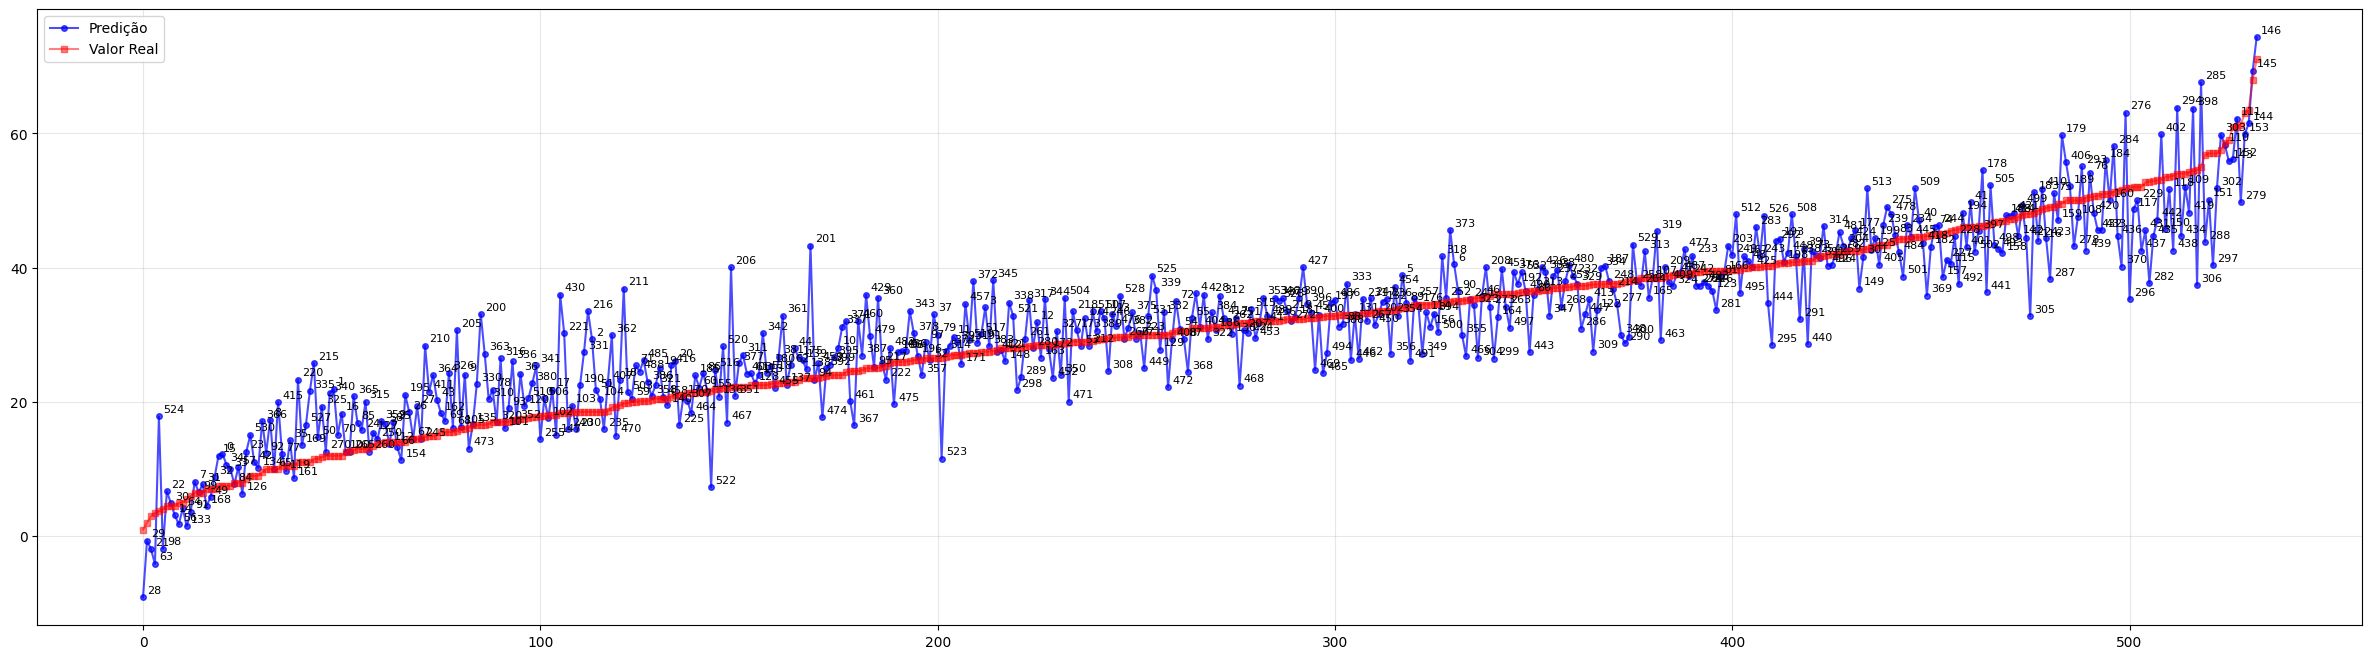

In [131]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [132]:

coverage = (ridge_results["covered"].mean())

print("Coverage:", coverage)

ridge_results['interval_width'] = (
    ridge_results['upper'] - ridge_results['lower']
)

ridge_results['error'] = (
    ridge_results['y_true'] - ridge_results['y_pred']
)

ridge_results['abs_error'] = (
    ridge_results['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

Coverage: 0.9174484052532833


In [133]:
below = (
    ridge_results["y_true"] < ridge_results["lower"]
).mean()

above = (
    ridge_results["y_true"] > ridge_results["upper"]
).mean()

print("Below:", below)
print("Above:", above)

print(
    "MAE:",
    ridge_results["abs_error"].mean()
)

print(
    "Mean interval width:",
    ridge_results["interval_width"].mean()
)

relative_width = (
    (ridge_results["upper"] - ridge_results["lower"]).mean()
    / ridge_results["y_true"].std()
)

print(f"Relative width: {relative_width}")

Below: 0.0450281425891182
Above: 0.0375234521575985
MAE: 4.067955585494394
Mean interval width: 20.789048101270286
Relative width: 1.5561074209465653


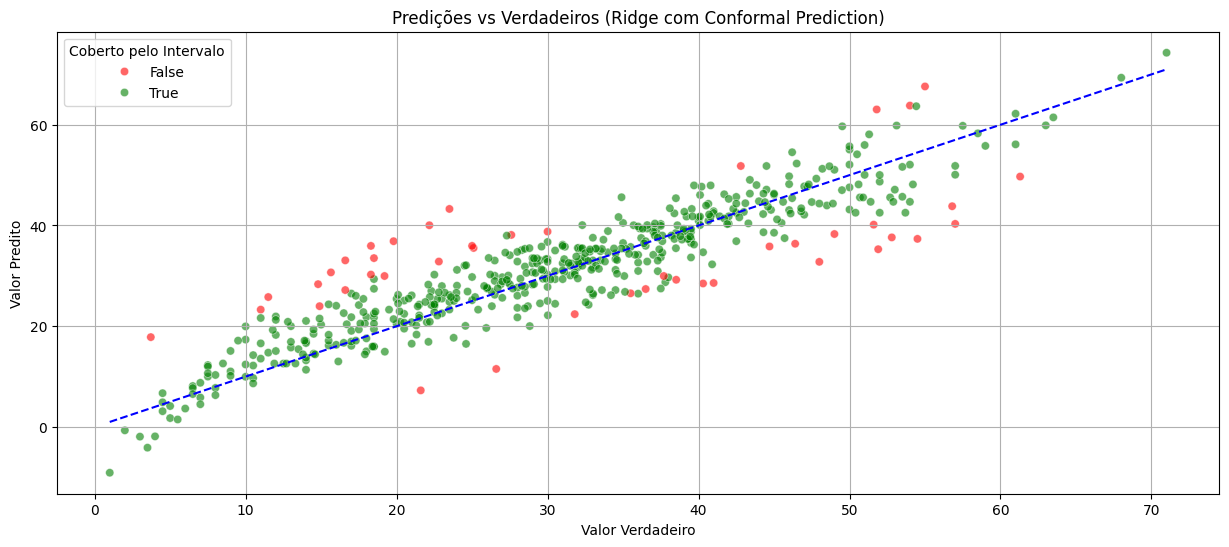

In [134]:
fold_summary = (
    ridge_results
    .groupby("group")
    .agg(
        coverage=("covered", "mean"),
        width=("interval_width", "mean"),
        mae=("abs_error", "mean")
    )
)

plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=ridge_results,
    x="y_true",
    y="y_pred",
    hue="covered",
    palette={True: "green", False: "red"},
    alpha=0.6
)
plt.plot(
    [ridge_results["y_true"].min(), ridge_results["y_true"].max()],
    [ridge_results["y_true"].min(), ridge_results["y_true"].max()],
    color="blue",
    linestyle="--"
)
plt.title("Predições vs Verdadeiros (Ridge com Conformal Prediction)")
plt.xlabel("Valor Verdadeiro")
plt.ylabel("Valor Predito")
plt.legend(title="Coberto pelo Intervalo")
plt.grid()
plt.show()

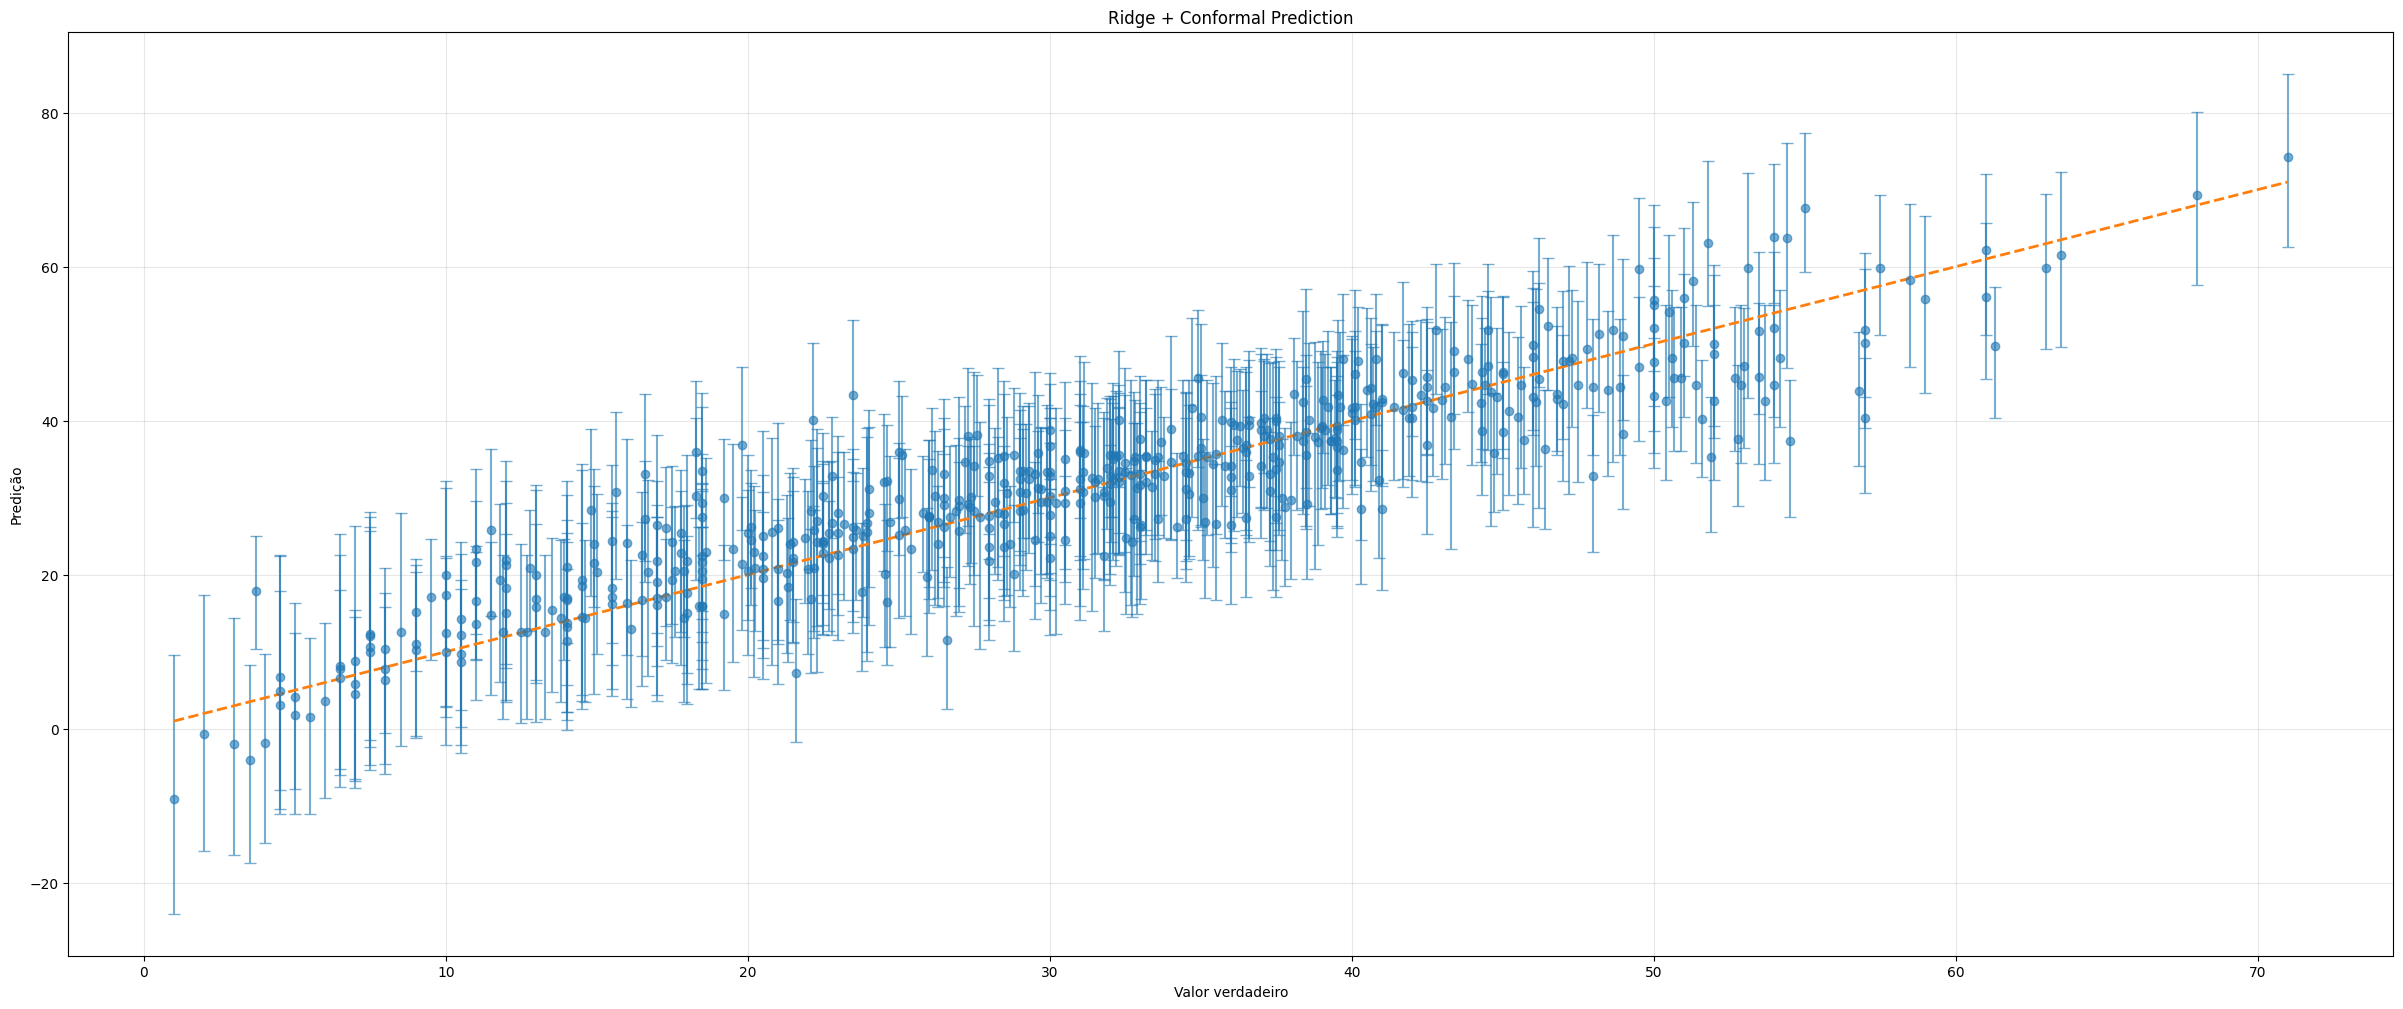

In [135]:
plot_df = ridge_results.sort_values("y_true")

plt.figure(figsize=(30, 12))

plt.errorbar(
    plot_df["y_true"],
    plot_df["y_pred"],
    yerr=[
        plot_df["y_pred"] - plot_df["lower"],
        plot_df["upper"] - plot_df["y_pred"]
    ],
    fmt="o",
    alpha=0.6,
    capsize=4
)

plt.plot(
    [plot_df["y_true"].min(), plot_df["y_true"].max()],
    [plot_df["y_true"].min(), plot_df["y_true"].max()],
    "--",
    linewidth=2
)

plt.xlabel("Valor verdadeiro")
plt.ylabel("Predição")
plt.title("Ridge + Conformal Prediction")
plt.grid(alpha=0.3)

plt.show()

## Observado vs Predito

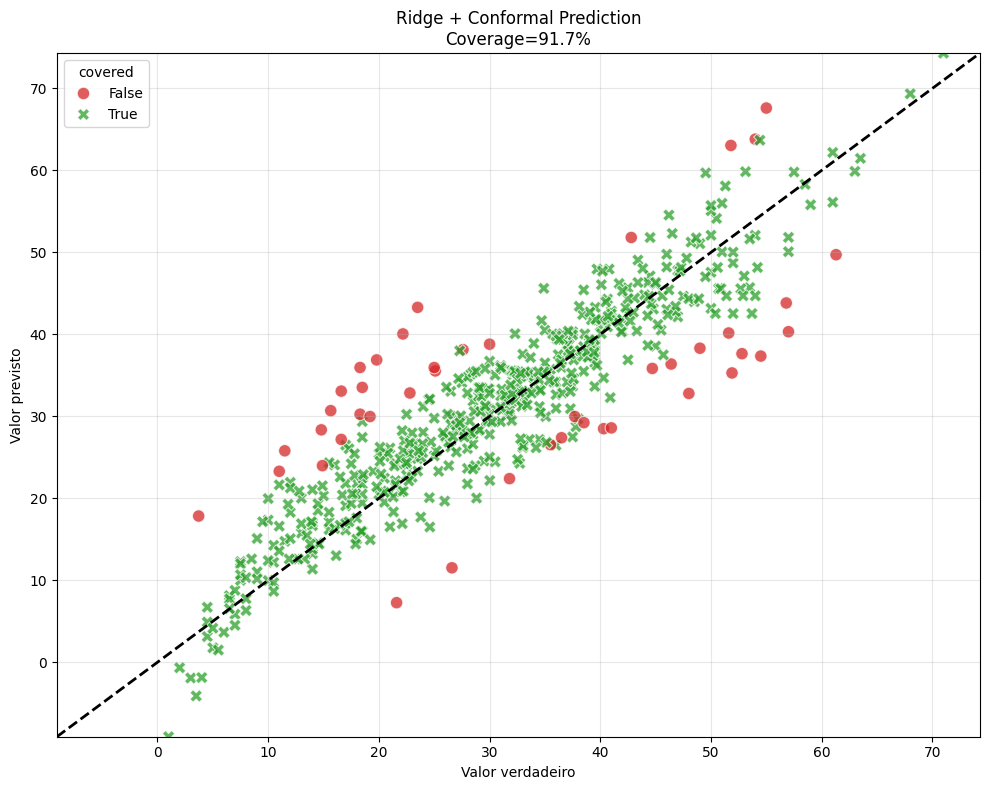

In [136]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=ridge_results,
    x="y_true",
    y="y_pred",
    hue="covered",
    style="covered",
    palette={
        True: "#2ca02c",
        False: "#d62728"
    },
    s=80,
    alpha=0.75
)

lims = [
    min(
        ridge_results["y_true"].min(),
        ridge_results["y_pred"].min()
    ),
    max(
        ridge_results["y_true"].max(),
        ridge_results["y_pred"].max()
    )
]

plt.plot(
    lims,
    lims,
    "--",
    linewidth=2,
    color="black",
    label="Predição perfeita"
)

plt.xlim(lims)
plt.ylim(lims)

plt.title(
    f"Ridge + Conformal Prediction\nCoverage={coverage:.1%}"
)

plt.xlabel("Valor verdadeiro")
plt.ylabel("Valor previsto")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

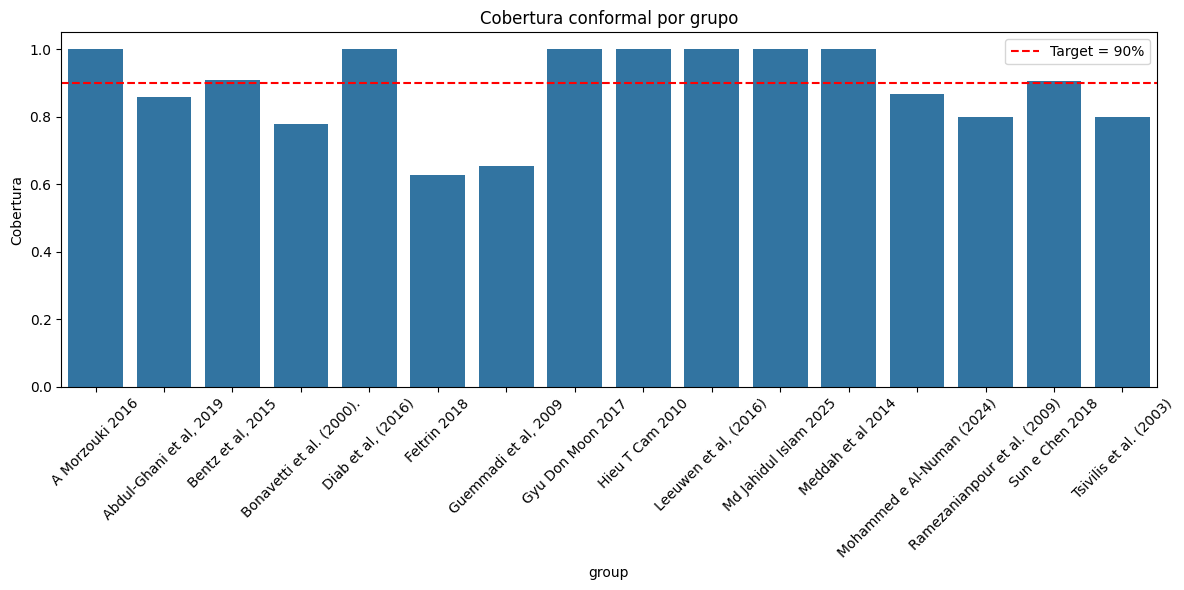

In [137]:
fold_summary = (
    ridge_results
    .groupby("group")
    .agg(
        coverage=("covered", "mean"),
        width=("interval_width", "mean"),
        mae=("abs_error", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=fold_summary,
    x="group",
    y="coverage"
)

plt.axhline(
    0.90,
    color="red",
    linestyle="--",
    label="Target = 90%"
)

plt.xticks(rotation=45)
plt.ylabel("Cobertura")
plt.title("Cobertura conformal por grupo")
plt.legend()

plt.tight_layout()
plt.show()

## Distribuição dos residuos

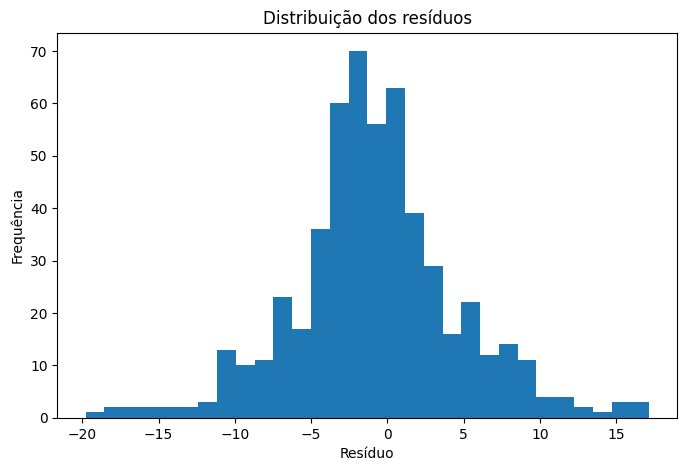

In [138]:
plt.figure(figsize=(8,5))

plt.hist(
    ridge_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

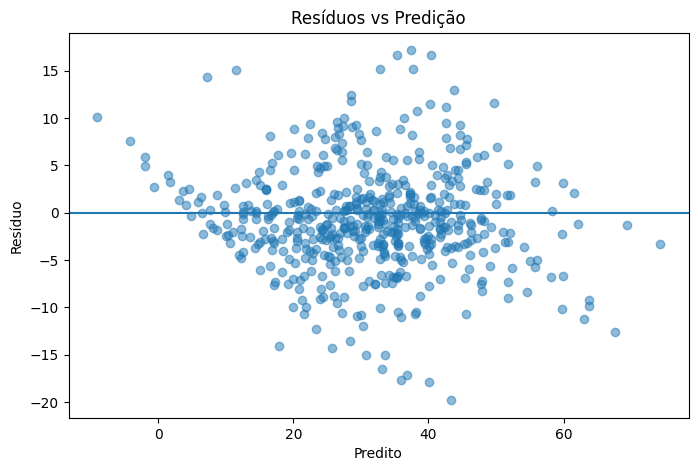

In [139]:
plt.figure(figsize=(8,5))

plt.scatter(
    ridge_results["y_pred"],
    ridge_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

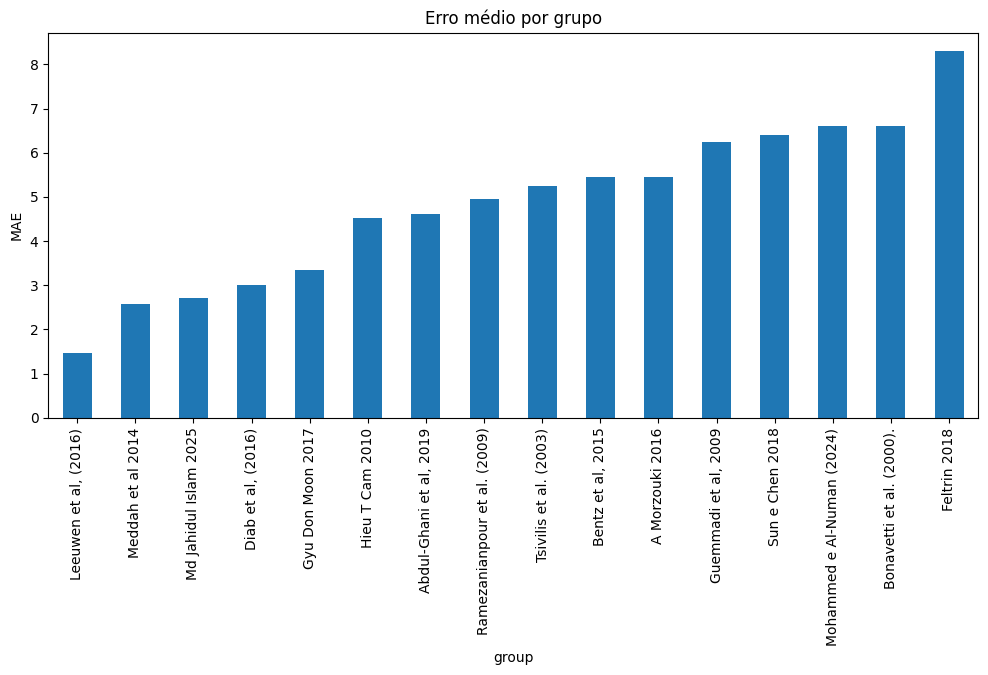

In [140]:
group_errors = (
    ridge_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [141]:
top_erros = (
    ridge_results
    .query("abs_error > 15")
    .sort_values("abs_error", ascending=False)
)

print(top_erros.index.tolist())

[201, 206, 430, 306, 211, 297, 296, 200, 305, 282, 523, 205, 216]


In [142]:
r2 = r2_score(ridge_results["y_true"], ridge_results["y_pred"])
rmse = root_mean_squared_error(ridge_results["y_true"], ridge_results["y_pred"])
mae = mean_absolute_error(ridge_results["y_true"], ridge_results["y_pred"])
mape = mean_absolute_percentage_error(ridge_results["y_true"], ridge_results["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.4826
mean_absolute_error: 4.0680
mean_absolute_percentage_error: 0.2012
R² Score: 83.1266
